# 红利低波原始指数编制

本 notebook 可从项目内任意目录运行。请按单元格分段执行：启动一个数据更新任务，按需控制或等待保存完成，再启动下一个任务。

In [1]:
import os
import sys
from pathlib import Path

search_paths = (Path.cwd(), *Path.cwd().parents)
project_root = next(path for path in search_paths if (path / "pyproject.toml").exists())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pyquant import load_dataset, update_dataset
from pyquant.io import load_config
from strategies.cross_sectional.dividend_low_vol.components import (
    calculate_dividend_low_vol_index,
    select_dividend_low_vol_download_symbols,
    select_dividend_low_vol_constituents,
)

plt.rcParams["font.family"] = "STHeiti"
plt.rcParams["axes.unicode_minus"] = False

## 调仓日期

`rebalance_date` 同时作为选样信息截止日和新指数段起点。本策略不区分选样日与生效日。

In [3]:
rebalance_date = pd.Timestamp("2013-12-16")
end_date = pd.Timestamp("2023-06-16")
history_start = rebalance_date - pd.DateOffset(years=3)
dividend_start = history_start - pd.DateOffset(years=1) if (rebalance_date.month == 12 and rebalance_date.day <= 20) else history_start
download_pool: str | list[str] = "all"
strategy_dir = project_root / "strategies/cross_sectional/dividend_low_vol"
config = load_config(strategy_dir / "config.yaml")
download_job = None

## 数据更新

三个数据集共用下载锁，因此同一时间只能运行一个任务。每个启动单元格会立即返回；开始下一个任务前，先等待当前任务完成，或执行停止并保存。行情可按 `download_pool` 下载；分红与股本仅下载整个下载区间内有至少 720 条有效行情的股票。若本地数据已经齐全，可跳过所有更新单元格，直接执行“通用数据集读取”。

In [ ]:
download_job = update_dataset(
    "stock_daily",
    start=history_start.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    pool=download_pool,
)

### 分红与股本下载股票池

此单元格只读取本地行情。它按整个下载区间内至少 720 条有效行情筛选股票，供后续分红和股本下载共用；因此一次下载可复用到该区间内的后续调仓日。

In [ ]:
price_for_download_pool = load_dataset(
    "stock_daily",
    start=history_start.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
download_pool = select_dividend_low_vol_download_symbols(
    price_for_download_pool,
    end_date,
    config,
)
if not download_pool:
    raise ValueError("No symbols have at least 720 valid prices in the download range")
print(f"Dividend/share download pool: {len(download_pool)} symbols")

### 下载控制

进度由启动单元格自动显示。暂停和继续不会丢失数据；“停止并保存”会等待待写数据、下载锁和登录会话处理完毕。

#### 暂停

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.pause()
download_job.state

#### 继续

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.resume()
download_job.state

#### 停止并保存

In [ ]:
if download_job is None:
    raise RuntimeError("No dataset update has been started")
download_job.stop()
download_job.wait()
download_job.state

### 分红数据

确认上一个任务已经完成或停止保存后，再执行本单元格。

In [ ]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

download_job = update_dataset(
    "dividend",
    start=dividend_start.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    pool=download_pool,
)

### 季度总股本

确认上一个任务已经完成或停止保存后，再执行本单元格。

In [ ]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

download_job = update_dataset(
    "stock_profit_quarterly",
    start=history_start.strftime("%Y-%m-%d"),
    end=rebalance_date.strftime("%Y-%m-%d"),
    pool=download_pool,
)

## 通用数据集读取

行情明确使用不复权口径；分红、查询覆盖和股本数据均通过数据集目录读取。

In [4]:
if download_job is not None:
    if download_job.state in {"running", "paused", "stopping"}:
        raise RuntimeError("Finish the active dataset update first")
    download_job.wait()

price = load_dataset(
    "stock_daily",
    start=history_start.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
dividends = load_dataset("dividend")
dividend_queries = load_dataset("dividend_queries")
shares = load_dataset("stock_profit_quarterly")

## 单次选样快照

In [5]:
constituents = select_dividend_low_vol_constituents(
    price,
    dividends,
    dividend_queries,
    shares,
    rebalance_date,
    config,
)
constituents[
    [
        "price_date",
        "avg_dividend_yield_3y",
        "dividend_yield_rank",
        "volatility_240d",
        "volatility_rank",
        "weight",
    ]
].sort_values("weight", ascending=False)

,price_date,avg_dividend_yield_3y,dividend_yield_rank,volatility_240d,volatility_rank,weight
symbol,,,,,,
sh.600177,2013-12-16,0.064601,1,0.024524,50,0.036285
sh.600660,2013-12-16,0.063533,2,0.018829,18,0.035685
sh.601988,2013-12-16,0.062049,3,0.011215,3,0.034851
sh.601939,2013-12-16,0.060414,4,0.013597,5,0.033933
sh.601398,2013-12-16,0.058218,5,0.011121,2,0.032699
sh.601006,2013-12-16,0.056870,6,0.017737,14,0.031943
sh.600004,2013-12-16,0.049220,7,0.015027,7,0.027645
sh.600900,2013-12-16,0.046996,8,0.012469,4,0.026396
sh.600028,2013-12-16,0.046173,9,0.022905,42,0.025934


## 单个调仓区间指数

首段两类指数均从 1000 点起算。未来拼接调仓区间时，将上一段调仓日收盘点位分别作为下一段的两个基点，并删除重复边界行。

In [6]:
index_segment = calculate_dividend_low_vol_index(
    price,
    dividends,
    dividend_queries,
    constituents,
    rebalance_date,
    end_date,
)
index_segment.tail()

,price_return,total_return,dividend_cash,price_index,total_return_index
date,,,,,
2023-06-12,0.001312,0.001312,0.000000,1853.509962,3105.205637
2023-06-13,0.001235,0.001235,0.000000,1855.798799,3109.040151
2023-06-14,0.001602,0.004500,0.005379,1858.771697,3123.031614
2023-06-15,0.009460,0.011024,0.002906,1876.356540,3157.458947
2023-06-16,0.003643,0.004078,0.000816,1883.191905,3170.334066


<Axes: title={'center': '红利低波价格指数与全收益指数'}, xlabel='date'>

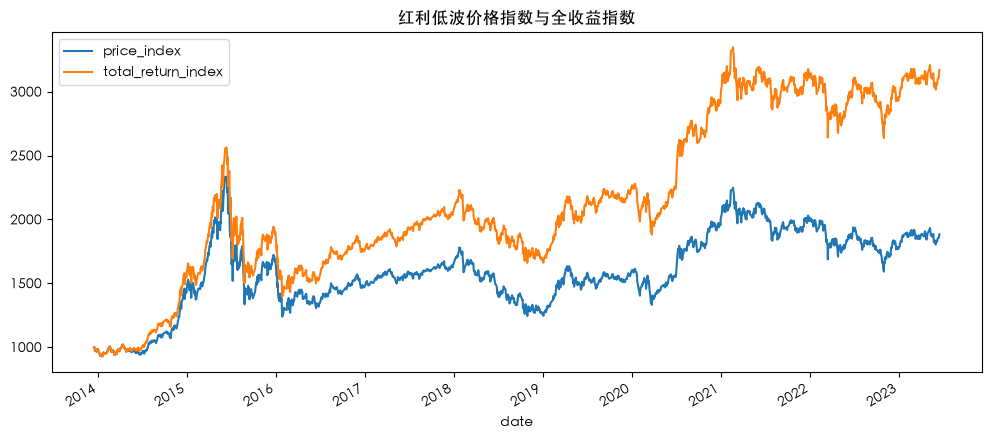

In [7]:
index_segment[["price_index", "total_return_index"]].plot(
    figsize=(12, 5),
    title="红利低波价格指数与全收益指数",
)